# 01 — Data exploration

**Goal:** get familiar with the wine dataset before modeling anything — shape, class balance, feature ranges, and whether the classes look separable at all.

**Input:** `sklearn.datasets.load_wine`, materialized to `data/raw/wine.csv` (see `data/README.md` for the full data card).

**Conclusion:** _(written after running the cells below — see the bottom of this notebook)_

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ucu-ai-course/project-template/blob/main/notebooks/01-data-exploration.ipynb)

In [1]:
import sys

# Safe to run locally too: this block only does anything inside Google Colab, where
# the repo isn't already cloned and the package isn't already installed.
if "google.colab" in sys.modules:
    get_ipython().system("git clone https://github.com/ucu-ai-course/project-template.git")
    get_ipython().run_line_magic("cd", "project-template")
    get_ipython().system("pip install -q -r requirements.txt")
    get_ipython().system("pip install -q -e .")


In [2]:
from pathlib import Path
import os

# Notebooks are launched from notebooks/ (`jupyter lab notebooks/`), but every path in this
# project (config/, data/, models/, results/) is written relative to the repo root.
# Running this cell once makes every relative path below "just work", the same way it
# does for the CLI and scripts/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
PROJECT_ROOT


PosixPath('/Users/oleksandr/Documents/GitHub/project-template')

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wine_origin.data import materialize_raw_csv

df = materialize_raw_csv("data/raw/wine.csv")
df.shape

(178, 14)

In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


class_0    59
class_1    71
class_2    48
Name: count, dtype: int64

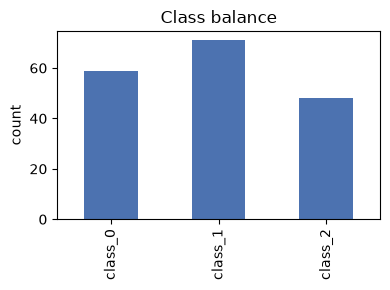

In [6]:
class_counts = df["target"].value_counts().sort_index()
class_counts.index = [f"class_{i}" for i in class_counts.index]

fig, ax = plt.subplots(figsize=(4, 3))
class_counts.plot.bar(ax=ax, color="#4C72B0")
ax.set_ylabel("count")
ax.set_title("Class balance")
fig.tight_layout()
class_counts

The classes are imbalanced (59 / 71 / 48) but not severely — this is why `data/README.md` flags it as a known limitation rather than something we corrected for (e.g. with resampling): it's mild enough that stratified splitting and macro-F1 are enough to handle it fairly.

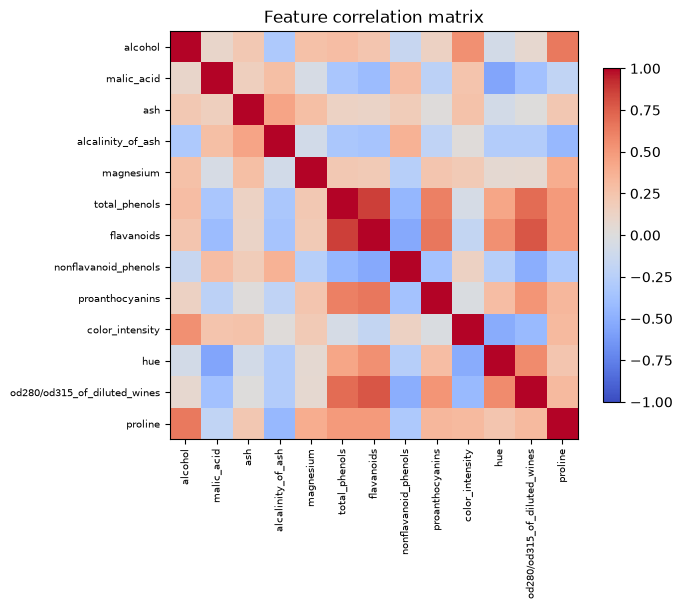

In [7]:
corr = df.drop(columns=["target"]).corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix")
fig.tight_layout()

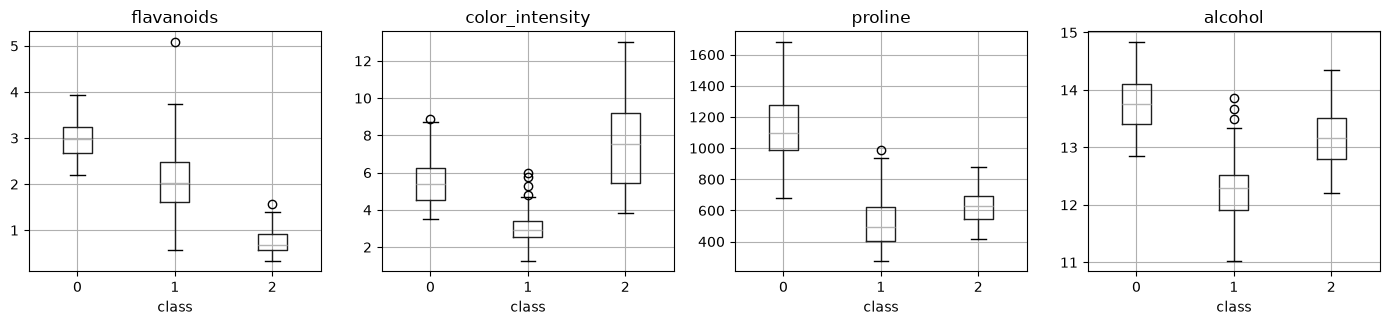

In [8]:
features_to_check = ["flavanoids", "color_intensity", "proline", "alcohol"]

fig, axes = plt.subplots(1, len(features_to_check), figsize=(14, 3.5))
for ax, feature in zip(axes, features_to_check):
    df.boxplot(column=feature, by="target", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("class")
fig.suptitle("")
fig.tight_layout()

## Conclusion

178 samples, 13 numeric features, 3 classes, no missing values, mild class imbalance (59/71/48). `flavanoids`, `color_intensity`, and `proline` visibly separate the three classes on their own in the boxplots above, and several features are strongly correlated with each other (e.g. `flavanoids` with `total_phenols`) — which is exactly the kind of dataset where even a linear model should do well. That's the expectation `02-baseline-model.ipynb` and `03-model-comparison.ipynb` test against a real baseline instead of just assuming.